# EDA – Gym Exercises Dataset

## Objectif

Vérifier que le fichier gym_exercises_dataset.csv est correctement chargé et obtenir une vue d’ensemble :

• dimensions du jeu de données (nombre de lignes et de colonnes) ;  
• typage des variables (champs textuels, listes de muscles, attributs techniques) ;  
• premières observations sur les valeurs manquantes et la présence éventuelle de doublons ;  
• cohérence générale du corpus avant analyse statistique et préparation NLP.


## Interprétation attendue

À partir de cette première inspection, il s’agira de commenter :

• la taille globale du dataset (nombre de lignes / colonnes) ;  
• la nature des variables (descriptifs textuels, attributs biomécaniques, catégories d’équipements) ;  
• la présence éventuelle de valeurs manquantes ou de champs textuels incomplets ;  
• l’existence (ou non) de doublons dans les données brutes ;  
• la cohérence générale des premières lignes (valeurs lisibles, descriptions complètes, muscles cohérents).

Cette interprétation sert de point de départ pour juger de la qualité du corpus et préparer les étapes suivantes : nettoyage, normalisation textuelle et structuration pour le traitement NLP du projet TrAIn.me.

## Configuration notebook

### Importation des librairies essentielles

In [22]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
import kagglehub
import prince

from pathlib import Path
import sys

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats

# === Localiser automatiquement le package 'themes' en remontant l'arborescence ===
root = Path.cwd()  # ex : .../train.me/src/notebooks/eda/health_fitness_dataset
themes_root = None

for p in [root, *root.parents]:
    if (p / "themes").is_dir():
        themes_root = p
        break

if themes_root is None:
    raise FileNotFoundError(
        f"Impossible de trouver le dossier 'themes' en partant de {root}. "
        "Vérifie l'arborescence : il doit exister un dossier 'themes/' quelque part au-dessus."
    )

if str(themes_root) not in sys.path:
    sys.path.insert(0, str(themes_root))

print("✅ Ajouté au PYTHONPATH :", themes_root)
print("📂 Contenu de", themes_root, ":", [x.name for x in themes_root.iterdir()])

from themes.theme_train_me import set_trainme_theme

✅ Ajouté au PYTHONPATH : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\notebooks
📂 Contenu de c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\notebooks : ['eda', 'model_training', 'preprocessing', 'themes', '__init__.py']


#### Configuration d’affichage et thème TrAIn.me


In [2]:
# Options d’affichage pour les tableaux
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# =============================
# Thème TrAIn.me (Seaborn/Matplotlib)
# =============================
USE_DARK_THEME = True  # bascule possible vers un thème clair si besoin

palette_trainme = set_trainme_theme(
    context="talk",
    font_scale=1.05,
    use_dark=USE_DARK_THEME
)

palette_trainme


['#00E5FF', '#00BFFF', '#0A84FF', '#1E90FF', '#00FFFF', '#64D8FF']

### Activation du thème TrAIn.me

In [3]:
if USE_DARK_THEME:
    palette_trainme = set_trainme_theme(context="talk", font_scale=1.05, use_dark=True)
else:
    sns.set_style("ticks")              # style clair sobre, axes renforcés
    sns.set_context("talk", font_scale=1.05)
    palette_trainme = sns.color_palette("deep")  # palette par défaut sobre
    print("🎨 Style activé : 'ticks' → sobre, axes renforcés (présentation pro)")

# Exemple de vérification :
print("Palette active :", palette_trainme.as_hex() if hasattr(palette_trainme, "as_hex") else palette_trainme)


Palette active : ['#00E5FF', '#00BFFF', '#0A84FF', '#1E90FF', '#00FFFF', '#64D8FF']


### 3.4.1. Chargement et inspection initiale

Cette section vise à charger le fichier gym_exercises_dataset.csv, vérifier ses dimensions
et obtenir un premier aperçu des données brutes. Elle reprend la même démarche que pour
les autres EDA du projet : contrôle du chargement, visualisation des premières lignes,
statistiques descriptives de base, analyse des valeurs manquantes et des doublons, puis
liste complète des colonnes disponibles.


#### Chargement du dataset gym_exercises_dataset.csv


In [4]:
# Téléchargement du dataset depuis Kaggle
dataset_path = kagglehub.dataset_download("rishitmurarka/gym-exercises-dataset")

# Recherche du fichier CSV dans le dossier téléchargé
csv_files = [f for f in os.listdir(dataset_path) if f.endswith(".csv")]
print("Fichiers trouvés :", csv_files)

# Construction du chemin complet vers le CSV
file_path = os.path.join(dataset_path, csv_files[0])


# Lecture du fichier CSV
df = pd.read_csv(file_path)

# Informations de confirmation
print("Dataset chargé avec succès !")
print(f"Dimensions : {df.shape[0]} lignes et {df.shape[1]} colonnes\n")


100%|██████████| 48.1k/48.1k [00:00<00:00, 574kB/s]

Extracting files...
Fichiers trouvés : ['gym_exercise_dataset.csv', 'stretch_exercise_dataset.csv']
Dataset chargé avec succès !
Dimensions : 617 lignes et 17 colonnes



#### Aperçu des premières lignes


In [5]:
df.head(10)


,Exercise Name,Equipment,Variation,Utility,Mechanics,Force,Preparation,Execution,Target_Muscles,Synergist_Muscles,Stabilizer_Muscles,Antagonist_Muscles,Dynamic_Stabilizer_Muscles,Main_muscle,Difficulty (1-5),Secondary Muscles,parent_id
0,Neck Flexion,Cable,No,Basic or Auxiliary,Isolated,Pull,Sit on bench facing away from middle pulley. P...,Move head away from pulley by bending neck for...,"Sternocleidomastoid,","None,","Rectus Abdominis, Obliques,",NaN,NaN,Neck,2,Sternocleidomastoid,NaN
1,Neck Flexion,Lever (plate loaded),No,Basic or Auxiliary,Isolated,Pull,Sit on seat in machine. Position padded lever ...,Move head forward by flexing neck until chin t...,"Sternocleidomastoid,","None,","Latissimus Dorsi, Deltoid, Posterior, Rhomboid...",NaN,NaN,Neck,2,Sternocleidomastoid,NaN
2,Lateral Neck Flexion,Lever (plate loaded),No,Auxiliary,Isolated,Pull,Sit on seat in machine with feet apart . Pos...,Move head down to side by laterally flexing ne...,"Sternocleidomastoid,","Splenius, Erector Spinae, Levator Scapulae, Tr...","Latissimus Dorsi, Pectoralis Major, Sternal, P...",NaN,NaN,Neck,2,"Sternocleidomastoid, Levator Scapulae",NaN
3,Neck Flexion,Lever (selectorized),No,Basic or Auxiliary,Isolated,Pull,Sit on seat in machine. Position padded lever ...,Move head forward by flexing neck until chin t...,"Sternocleidomastoid,","None,","Latissimus Dorsi, Deltoid, Posterior, Rhomboid...",NaN,NaN,Neck,2,Sternocleidomastoid,NaN
4,Lateral Neck Flexion,Lever (selectorized),No,Auxiliary,Isolated,Pull,Sit on seat in machine with feet apart. Positi...,Move head down to side by laterally flexing ne...,"Sternocleidomastoid,","Splenius, Erector Spinae, Levator Scapulae, Tr...","Latissimus Dorsi, Pectoralis Major, Sternal, P...",NaN,NaN,Neck,2,"Sternocleidomastoid, Levator Scapulae",NaN
5,Neck Flexion,Weighted,No,Basic or Auxiliary,Isolated,Pull,Place folded towel on weight plate. Lie supine...,Move head up by flexing neck until chin touche...,"Sternocleidomastoid,","None,","Rectus Abdominis, Obliques,",NaN,NaN,Neck,2,Sternocleidomastoid,NaN
6,Lateral Neck Flexion,Weighted,No,Auxiliary,Isolated,Pull,Place folded towel on weight plate. Lie on ben...,Move head up to side by laterally flexing neck...,"Sternocleidomastoid,","Splenius, Erector Spinae, Levator Scapulae, Tr...",NaN,NaN,NaN,Neck,2,"Sternocleidomastoid, Levator Scapulae",NaN
7,Wall Front Neck Bridge,Body Weight,No,Basic or Auxiliary,Isolated,Push & Pull,Place small or folded cushioned mat on wall or...,Roll down onto forehead until nose touches mat...,"Sternocleidomastoid,","Splenius, Trapezius, Upper, Levator Scapulae, ...","Rectus Abdominis, Obliques, Quadriceps,","Erector Spinae,",NaN,Neck,3,"Sternocleidomastoid, Upper Trapezius",NaN
8,Wall Side Neck Bridge,Body Weight,No,Auxiliary,Isolated,Pull,Place small or folded cushioned mat on column ...,Push side of head into mat and roll onto top o...,"Sternocleidomastoid,","Splenius, Trapezius, Upper, Levator Scapulae, ...","Gluteus Medius, Gluteus Minimus,",NaN,NaN,Neck,3,"Sternocleidomastoid, Upper Trapezius",NaN
9,Neck Flexion,Suspended,No,Basic or Auxiliary,Isolated,Pull,Place belt or strap around end of suspension t...,Increase angle of body by bowing head until ch...,"Sternocleidomastoid,","Splenius, Trapezius, Upper, Erector Spinae, Ce...",NaN,NaN,NaN,Neck,2,Sternocleidomastoid,NaN


#### Informations sur le typage, les valeurs manquantes et les doublons


In [6]:
# Typage et complétude globale
df_info = df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 617 entries, 0 to 616
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Exercise Name               617 non-null    object 
 1   Equipment                   617 non-null    object 
 2   Variation                   613 non-null    object 
 3   Utility                     617 non-null    object 
 4   Mechanics                   617 non-null    object 
 5   Force                       617 non-null    object 
 6   Preparation                 617 non-null    object 
 7   Execution                   617 non-null    object 
 8   Target_Muscles              617 non-null    object 
 9   Synergist_Muscles           615 non-null    object 
 10  Stabilizer_Muscles          489 non-null    object 
 11  Antagonist_Muscles          141 non-null    object 
 12  Dynamic_Stabilizer_Muscles  265 non-null    object 
 13  Main_muscle                 617 non

### Statistiques descriptives des variables numériques

In [7]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Difficulty (1-5),617.0,2.737439,0.893215,1.0,2.0,3.0,3.0,5.0
parent_id,161.0,307.248447,158.649536,14.0,181.0,341.0,449.0,615.0


### Analyse des valeurs manquantes et doublons

In [8]:
# Comptage des valeurs manquantes par colonne
missing_counts = df.isna().sum().sort_values(ascending=False)

print("\n🔎 Valeurs manquantes par colonne (top 20) :")
display(missing_counts.head(20))

# Comptage des doublons ligne à ligne
n_duplicates = df.duplicated().sum()
print(f"\n🧬 Nombre de doublons (lignes strictement identiques) : {n_duplicates}")


🔎 Valeurs manquantes par colonne (top 20) :


Antagonist_Muscles            476
parent_id                     456
Dynamic_Stabilizer_Muscles    352
Stabilizer_Muscles            128
Variation                       4
Synergist_Muscles               2
Secondary Muscles               1
Difficulty (1-5)                0
Main_muscle                     0
Exercise Name                   0
Equipment                       0
Execution                       0
Preparation                     0
Force                           0
Mechanics                       0
Utility                         0
Target_Muscles                  0
dtype: int64


🧬 Nombre de doublons (lignes strictement identiques) : 0


#### Liste complète des colonnes disponibles


In [9]:
print("\n--- Liste des colonnes du dataset ---")
print(df.columns.tolist())



--- Liste des colonnes du dataset ---
['Exercise Name', 'Equipment', 'Variation', 'Utility', 'Mechanics', 'Force', 'Preparation', 'Execution', 'Target_Muscles', 'Synergist_Muscles', 'Stabilizer_Muscles', 'Antagonist_Muscles', 'Dynamic_Stabilizer_Muscles', 'Main_muscle', 'Difficulty (1-5)', 'Secondary Muscles', 'parent_id']


## Statistiques descriptives et distribution des variables

### Objectif

Obtenir une vue d’ensemble chiffrée des variables numériques du dataset :

- résumer la distribution des variables disponibles (Difficulty (1-5), parent_id) ;
- repérer les ordres de grandeur, la dispersion et les éventuelles valeurs extrêmes ;
- identifier la répartition des niveaux de difficulté des exercices ;
- préparer l’identification d’outliers et la sélection de variables pertinentes pour la suite de l’analyse.


### Interprétation attendue

À l’issue de cette section, l’interprétation devra mettre en évidence :

- la distribution des niveaux de difficulté des exercices (répartition sur l’échelle 1–5) ;
- le rôle de parent_id comme identifiant de regroupement plutôt que comme variable métier ;
- la présence éventuelle de valeurs extrêmes ou atypiques sur les variables numériques ;
- les premières tendances sur la structure du corpus (exercices majoritairement faciles, intermédiaires ou difficiles).

Ces éléments guideront la suite de l’EDA, notamment la détection d’anomalies et la préparation des features pour les futurs modèles NLP et de recommandation.


### Statistiques descriptives globales


In [10]:
# --- Colonnes numériques disponibles ---
num_cols = df.select_dtypes(include="number").columns.tolist()
print(f"Variables numériques détectées ({len(num_cols)}) : {num_cols}")

# Statistiques descriptives de base
stats_num = df[num_cols].describe().T
display(stats_num)

# Quelques repères métier
if "Difficulty (1-5)" in df.columns:
    print(f"\nDifficulté moyenne : {df['Difficulty (1-5)'].mean():.2f} / 5")
    print("Répartition des niveaux de difficulté :")
    display(df["Difficulty (1-5)"].value_counts().sort_index())


Variables numériques détectées (2) : ['Difficulty (1-5)', 'parent_id']


,count,mean,std,min,25%,50%,75%,max
Difficulty (1-5),617.0,2.737439,0.893215,1.0,2.0,3.0,3.0,5.0
parent_id,161.0,307.248447,158.649536,14.0,181.0,341.0,449.0,615.0



Difficulté moyenne : 2.74 / 5
Répartition des niveaux de difficulté :


Difficulty (1-5)
1     41
2    209
3    254
4     97
5     16
Name: count, dtype: int64

### Distribution des variables clés


Variables numériques représentées : ['Difficulty (1-5)']


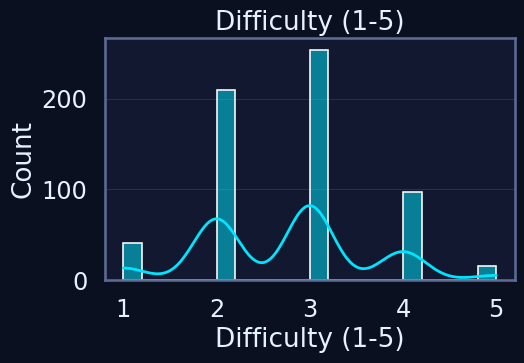

In [11]:
# On garde les variables numériques réellement intéressantes
num_vars = [c for c in num_cols if c != "parent_id"]  # parent_id = identifiant technique
print(f"Variables numériques représentées : {num_vars}")

n = len(num_vars)
if n == 0:
    print("ℹ️ Aucune variable numérique pertinente à visualiser.")
else:
    n_cols = 2
    n_rows = int(np.ceil(n / n_cols))

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_vars, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], bins=20, kde=True)
        plt.title(col)
        plt.grid(True, axis="y")

    plt.tight_layout()
    plt.show()


### Boxplots pour repérer les outliers


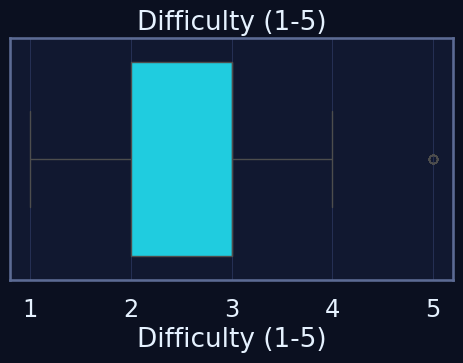

In [12]:
if num_vars:
    plt.figure(figsize=(5 * len(num_vars), 4))

    for i, col in enumerate(num_vars, 1):
        plt.subplot(1, len(num_vars), i)
        sns.boxplot(x=df[col])
        plt.title(col)
        plt.grid(True, axis="x")

    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ Aucun boxplot pertinent à afficher (pas de variable numérique métier).")


### Statistiques descriptives enrichies


In [13]:
if num_cols:
    desc = df[num_cols].describe().T
    desc["missing_%"] = df[num_cols].isna().mean() * 100
    desc["zeros_%"] = (df[num_cols] == 0).mean() * 100
    desc["skew"] = df[num_cols].skew()
    desc["kurt"] = df[num_cols].kurt()

    display(desc.sort_values("std", ascending=False))
else:
    print("ℹ️ Aucune variable numérique disponible pour des statistiques enrichies.")


,count,mean,std,min,25%,50%,75%,max,missing_%,zeros_%,skew,kurt
parent_id,161.0,307.248447,158.649536,14.0,181.0,341.0,449.0,615.0,73.905997,0.0,-0.197914,-1.036210
Difficulty (1-5),617.0,2.737439,0.893215,1.0,2.0,3.0,3.0,5.0,0.000000,0.0,0.197199,-0.175658


### Détection rapide d’outliers (IQR)


In [14]:
iqr_report = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    iqr_report[col] = len(outliers)

iqr_df = pd.DataFrame.from_dict(iqr_report, orient="index", columns=["outliers"])
iqr_df.sort_values("outliers", ascending=False)


,outliers
Difficulty (1-5),16
parent_id,0


### Aperçu corrélations (sous-ensemble lisible)


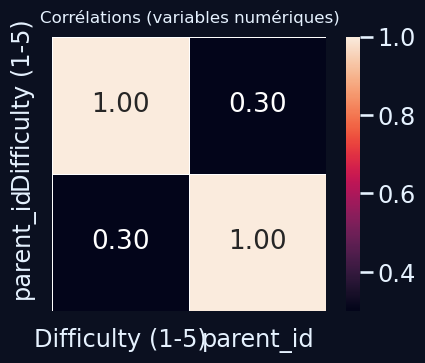

In [15]:
if len(num_cols) >= 2:
    subset_cols = num_cols  # très peu de variables numériques ici
    corr = df[subset_cols].corr(numeric_only=True)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        square=True,
        cbar=True,
        linewidths=0.5,
    )
    plt.title("Corrélations (variables numériques)", fontsize=12, pad=10)
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ Corrélation non pertinente : une seule variable numérique disponible.")


## Visualisation univariée

### Objectif

Compléter les statistiques descriptives par une analyse visuelle des distributions
des variables numériques du dataset.

Dans le cas du Gym Exercises Dataset, il s’agit principalement de :

- visualiser la répartition des niveaux de difficulté (Difficulty (1-5)) ;
- vérifier l’éventuelle présence de valeurs extrêmes ou atypiques ;
- confirmer le rôle de parent_id comme identifiant technique plus que comme
  variable métier continue ;
- préparer les décisions de nettoyage ou de regroupement éventuel pour la suite
  de l’analyse.


### Interprétation attendue

À l’issue de cette section, l’analyse devra :

- décrire la forme de la distribution de Difficulty (1-5) (niveau dominant,
  éventuel déséquilibre entre exercices faciles et difficiles) ;
- signaler la présence ou non de niveaux très peu représentés ;
- confirmer le caractère peu informatif de parent_id en tant que variable
  numérique (utilisation structurelle, valeurs dispersées) ;
- identifier visuellement d’éventuels points atypiques qui pourraient justifier
  un traitement spécifique dans les étapes suivantes.

Ces éléments complètent la lecture purement chiffrée et orientent les choix de
préparation des features pour les futurs modèles NLP et de recommandation.


### Sélection robuste des variables numériques à visualiser


In [16]:
# --- Sélection des variables numériques pertinentes pour la visualisation univariée ---

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
print("Variables numériques détectées :", num_cols)

# On conserve Difficulty (1-5) comme variable métier principale
# et on laisse parent_id optionnel (identifiant technique de regroupement)
vars_univariate = [c for c in num_cols if c == "Difficulty (1-5)"]

print("Variables retenues pour la visualisation univariée :", vars_univariate)


Variables numériques détectées : ['Difficulty (1-5)', 'parent_id']
Variables retenues pour la visualisation univariée : ['Difficulty (1-5)']


### Visualisation des distributions univariées (hist + KDE)


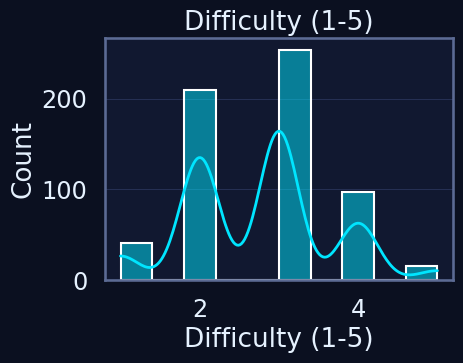

In [17]:
if not vars_univariate:
    print("ℹ️ Aucune variable numérique pertinente à visualiser.")
else:
    n = len(vars_univariate)
    n_cols = min(3, n)
    n_rows = int(np.ceil(n / n_cols))

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(vars_univariate, start=1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], bins=10, kde=True)
        plt.title(col)
        plt.grid(True, axis="y")

    plt.tight_layout()
    plt.show()


### Boxplots univariés pour détection visuelle d'outliers


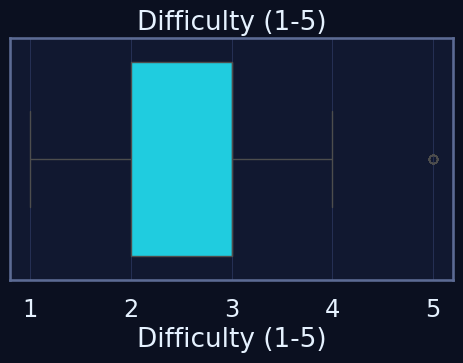

In [18]:
if not vars_univariate:
    print("ℹ️ Aucun boxplot pertinent à afficher (pas de variable numérique métier).")
else:
    plt.figure(figsize=(5 * len(vars_univariate), 4))

    for i, col in enumerate(vars_univariate, start=1):
        plt.subplot(1, len(vars_univariate), i)
        sns.boxplot(x=df[col])
        plt.title(col)
        plt.grid(True, axis="x")

    plt.tight_layout()
    plt.show()


## 3.4.4. Visualisation bivariée

### Objectif

Explorer les relations entre la variable numérique de difficulté (*Difficulty (1-5)*)
et les principales variables catégorielles du corpus (Equipment, Main_muscle,
Utility, etc.).

L’objectif est de :

- comprendre comment la difficulté se répartit selon les types d’équipement
  et les groupes musculaires ;
- analyser les co-occurrences entre catégories (combinaisons Equipment ×
  Main_muscle, par exemple) ;
- identifier les types d’exercices les plus représentés au sein des machines
  les plus utilisées.

Ces éléments permettront de mieux structurer le catalogue d’exercices pour les
futurs modèles de recommandation et de NLP.


### Interprétation attendue

À l’issue de cette section, l’analyse devra :

- mettre en évidence les équipements associés aux niveaux de difficulté les
  plus élevés ou les plus faibles ;
- décrire les couples de catégories fréquents (par exemple Equipment ×
  Main_muscle) et leurs patterns ;
- visualiser la répartition des types d’exercices (Utility) au sein des
  équipements les plus présents ;
- dégager des pistes sur la manière dont la difficulté se combine avec
  l’équipement et les groupes musculaires.

Ces observations aideront à concevoir des règles métiers et à orienter le
pré-traitement des textes (catégorisation, regroupements, mappings pour le NLP).


### Relations catégorielles ↔ numérique (Difficulty (1-5))

Dans un premier temps, on observe comment la difficulté moyenne des exercices
évolue selon l’équipement utilisé et le muscle principal ciblé.


,count,mean
Equipment,,
Assisted (machine),3,4.000000
Assisted (partner),2,4.000000
Band-assisted,7,3.857143
Suspension,2,3.500000
Self-assisted,6,3.500000
Plyometric,2,3.500000
Self-assisted​​​​​​​,5,3.400000
Body Weight,76,3.315789
Weighted,34,3.205882


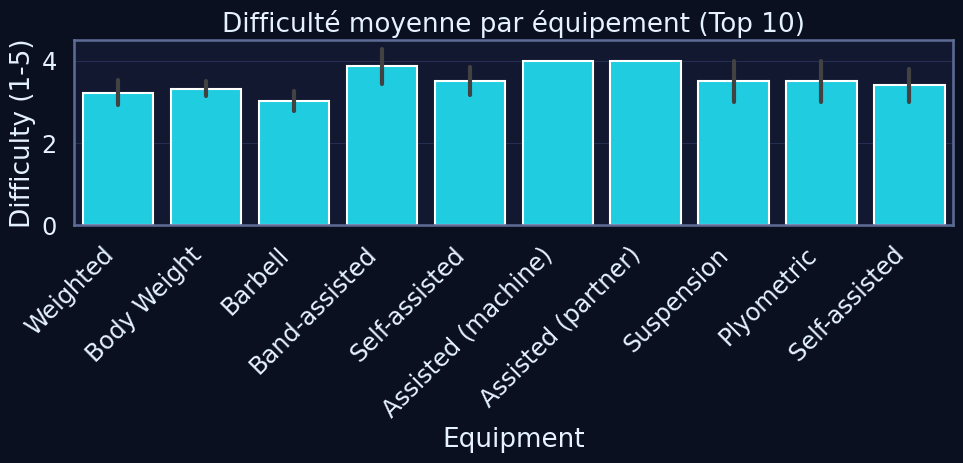

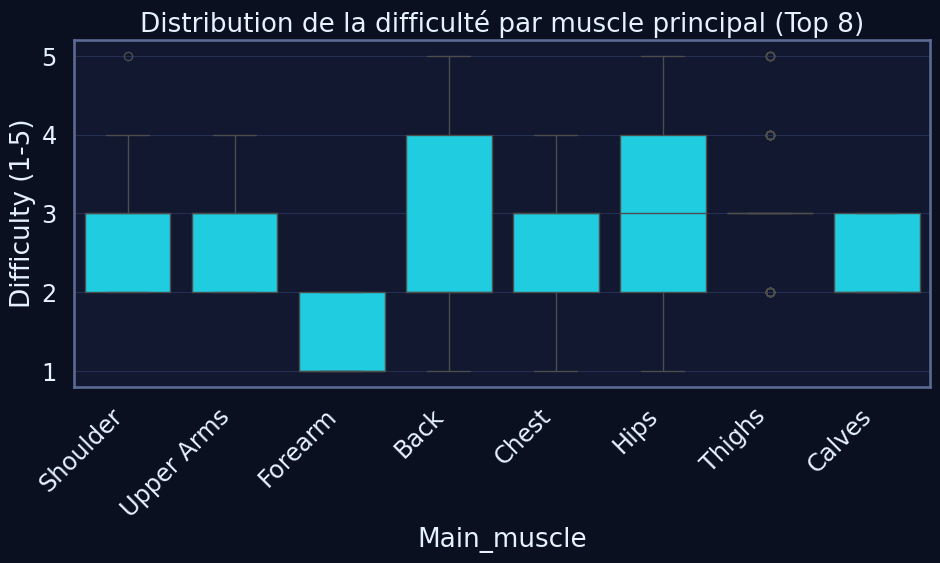

In [19]:
rating_col = "Difficulty (1-5)"

# --- Difficulté moyenne par équipement ---
equip_rating = (
    df.groupby("Equipment")[rating_col]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

display(equip_rating.head(15))

plt.figure(figsize=(10, 5))
top_equip = equip_rating.head(10).index

sns.barplot(
    data=df[df["Equipment"].isin(top_equip)],
    x="Equipment",
    y=rating_col,
    estimator=np.mean,
)
plt.xticks(rotation=45, ha="right")
plt.title("Difficulté moyenne par équipement (Top 10)")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

# --- Difficulté par muscle principal (boxplots) ---
plt.figure(figsize=(10, 6))
top_muscles = (
    df["Main_muscle"]
    .value_counts()
    .head(8)
    .index
)

sns.boxplot(
    data=df[df["Main_muscle"].isin(top_muscles)],
    x="Main_muscle",
    y=rating_col,
)
plt.xticks(rotation=45, ha="right")
plt.title("Distribution de la difficulté par muscle principal (Top 8)")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()


### Co-occurrences entre catégories (crosstab + heatmaps)

On s’intéresse ensuite aux co-occurrences entre catégories, par exemple les
combinaisons Equipment × Main_muscle, pour repérer les couples les plus
fréquents.


Main_muscle,Back,Calves,Chest,Forearm,Hips,Shoulder,Thighs,Upper Arms
Equipment,,,,,,,,
Barbell,5,3,5,3,14,5,15,7
Body Weight,10,4,8,0,26,4,14,7
Cable,21,4,12,4,18,16,9,15
Dumbbell,7,4,7,5,8,15,8,8
Lever (plate loaded),16,9,7,3,14,7,12,5
Lever (selectorized),11,8,13,6,14,6,12,7
Sled,1,12,1,0,9,1,6,1
Weighted,4,1,2,0,16,0,5,2


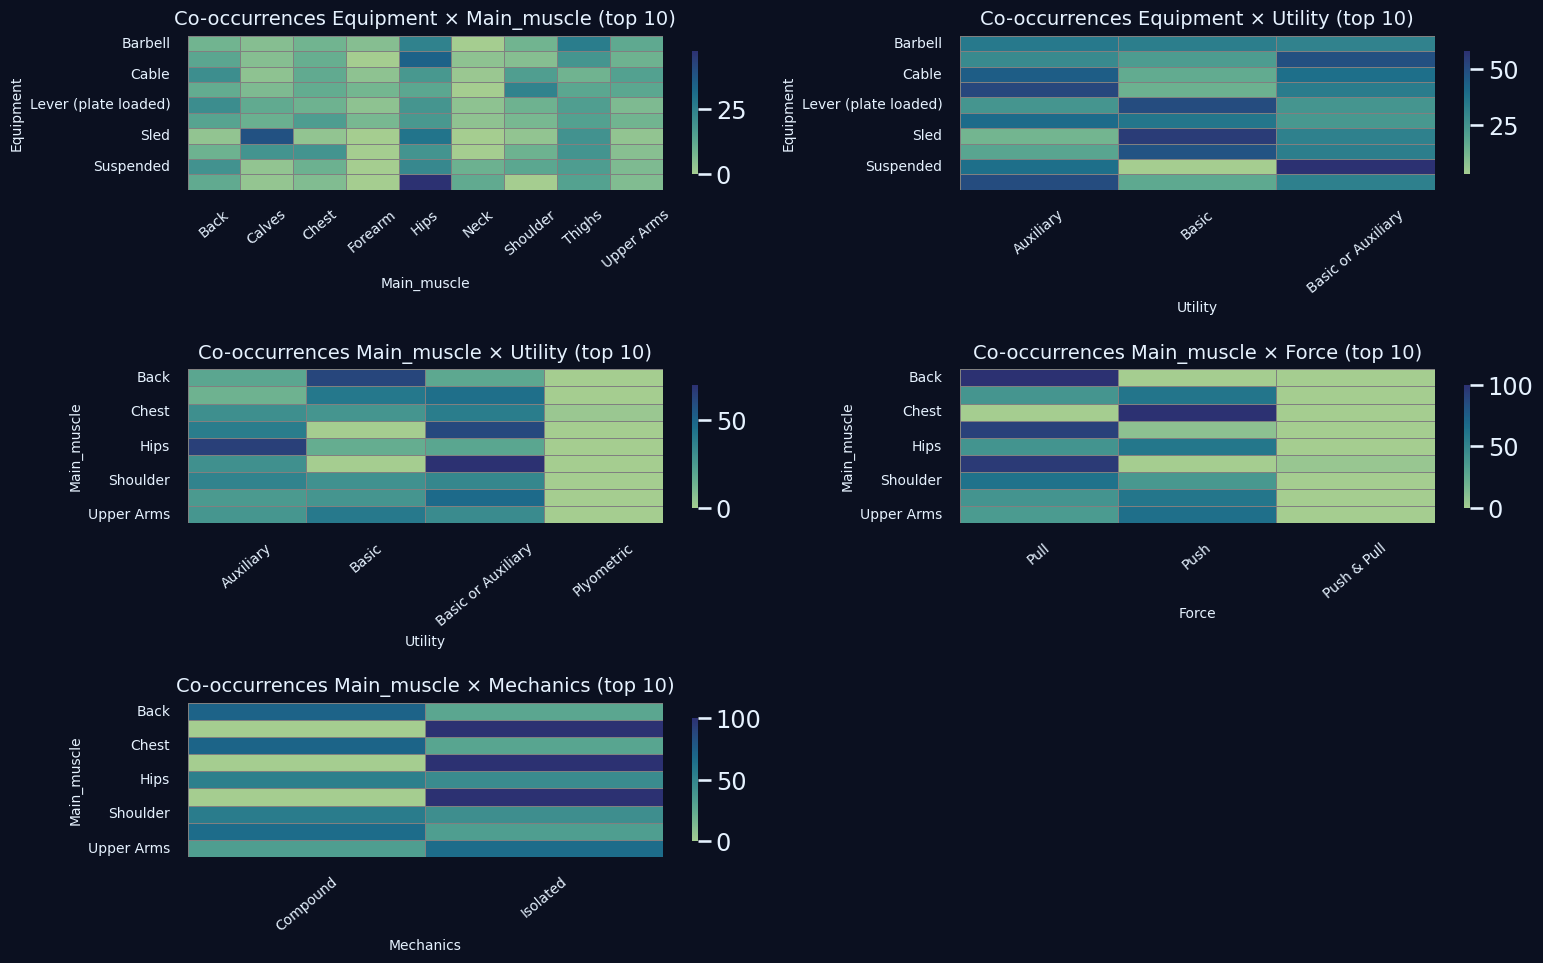

In [23]:
# Sélection d'un sous-ensemble lisible : top équipements / top muscles
top_equip_for_cooc = df["Equipment"].value_counts().head(8).index
top_muscles_for_cooc = df["Main_muscle"].value_counts().head(8).index

subset = df[
    df["Equipment"].isin(top_equip_for_cooc)
    & df["Main_muscle"].isin(top_muscles_for_cooc)
]

cooc = pd.crosstab(subset["Equipment"], subset["Main_muscle"])

display(cooc)

def plot_crosstab_heatmaps(
    df,
    pairs,
    top_k=12,
    normalize=None,     # None | "row" | "col"  (pourcentages)
    annotate=False,     # True pour afficher les valeurs
    log_color=False,    # True pour mieux voir les faibles valeurs
    figsize=(16, 9),
    title_fontsize=13,
    tick_fontsize=9,
    label_rotation_x=30,
    label_rotation_y=0,
    cbar_shrink=0.85
):
    """Heatmaps propres et lisibles pour analyser les co-occurrences de catégories."""
    if not pairs:
        print("ℹ️ Aucune paire de catégories disponible.")
        return

    n = len(pairs)
    ncols = 2
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()

    for i, (a, b) in enumerate(pairs):
        ax = axes[i]

        # Top-k pour réduire la cardinalité (plus lisible)
        a_top = df[a].value_counts().index[:top_k]
        b_top = df[b].value_counts().index[:top_k]
        sub = df[df[a].isin(a_top) & df[b].isin(b_top)]

        ct = pd.crosstab(sub[a], sub[b])

        # Normalisation optionnelle en pourcentages
        if normalize in {"row", "col"}:
            axis = 1 if normalize == "row" else 0
            ct = (
                ct.div(
                    ct.sum(axis=axis).replace(0, np.nan),
                    axis=1-axis
                ) * 100
            ).round(1)

        # Palette & échelle adaptées
        heatmap_kwargs = dict(
            cmap="crest",
            linewidths=0.4,
            linecolor="grey",
            cbar_kws={"shrink": cbar_shrink},
            square=False,
        )
        if log_color and normalize is None:
            # Log uniquement pour les comptes bruts (pas en %)
            vmin = max(ct.replace(0, np.nan).min().min(), 1e-6)
            vmax = ct.max().max()
            heatmap_kwargs["norm"] = LogNorm(vmin=vmin, vmax=vmax)

        # Annotations optionnelles
        if annotate:
            sns.heatmap(
                ct,
                ax=ax,
                **heatmap_kwargs,
                annot=True,
                fmt=".1f" if normalize else "g",
                annot_kws={"fontsize": max(tick_fontsize - 1, 7)},
            )
        else:
            sns.heatmap(ct, ax=ax, **heatmap_kwargs)

        ax.set_title(
            f"Co-occurrences {a} × {b} (top {top_k})",
            fontsize=title_fontsize,
            pad=8,
        )
        ax.set_xlabel(b, fontsize=10)
        ax.set_ylabel(a, fontsize=10)

        # Ticks propres
        ax.tick_params(axis="x", labelsize=tick_fontsize, rotation=label_rotation_x)
        ax.tick_params(axis="y", labelsize=tick_fontsize, rotation=label_rotation_y)
        ax.grid(False)

    # Masquer axes vides si nombre impair
    for j in range(i + 1, nrows * ncols):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


# ============================================================
# Sélection des paires & appel (version Gym Exercises Dataset)
# ============================================================
pairs = []
if {"Equipment", "Main_muscle"}.issubset(df.columns):
    pairs.append(("Equipment", "Main_muscle"))
if {"Equipment", "Utility"}.issubset(df.columns):
    pairs.append(("Equipment", "Utility"))
if {"Main_muscle", "Utility"}.issubset(df.columns):
    pairs.append(("Main_muscle", "Utility"))
if {"Main_muscle", "Force"}.issubset(df.columns):
    pairs.append(("Main_muscle", "Force"))
if {"Main_muscle", "Mechanics"}.issubset(df.columns):
    pairs.append(("Main_muscle", "Mechanics"))

# 👉 Paramètres recommandés pour notre dataset :
# - normalize="row" pour lire des ratios par catégorie de ligne
# - annotate=False pour éviter la surcharge visuelle
# - log_color=False car on travaille en %
plot_crosstab_heatmaps(
    df,
    pairs=pairs,
    top_k=10,
    normalize="row",     # None = comptes bruts ; "row"/"col" = pourcentages
    annotate=False,
    log_color=False,
    figsize=(16, 10),
    title_fontsize=14,
    tick_fontsize=10,
    label_rotation_x=40,
    label_rotation_y=0,
    cbar_shrink=0.8,
)



### Comptage empilé (stacked) : Type au sein du top Equipment

Pour finir, on observe la répartition des types d’exercices (Utility :
Basic or Auxiliary / Auxiliary, etc.) au sein des équipements les plus
représentés.


Utility,Auxiliary,Basic,Basic or Auxiliary
Equipment,,,
Barbell,20,19,18
Body Weight,22,17,37
Cable,45,17,39
Dumbbell,32,9,21
Lever (plate loaded),19,38,19
Lever (selectorized),32,29,19


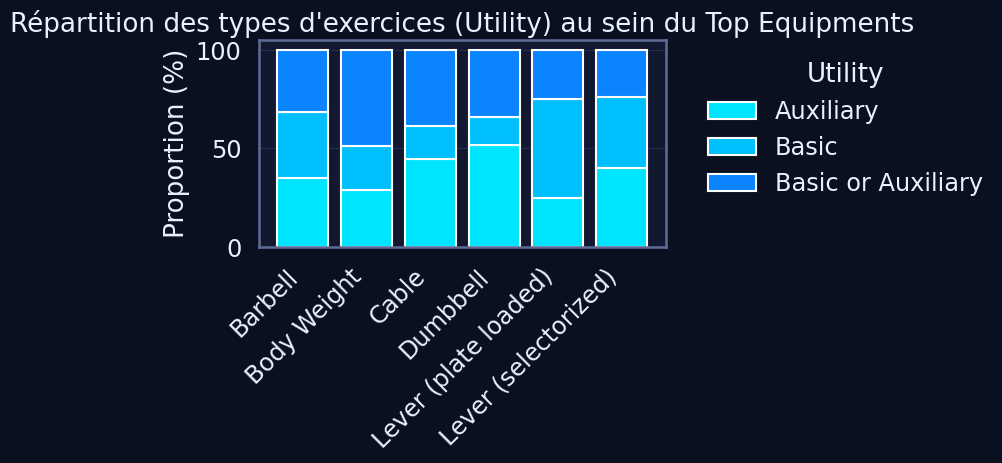

In [24]:
# On retient les équipements les plus fréquents
top_equip_for_stack = df["Equipment"].value_counts().head(6).index
stack_subset = df[df["Equipment"].isin(top_equip_for_stack)].copy()

crosstab_utility = pd.crosstab(stack_subset["Equipment"], stack_subset["Utility"])
display(crosstab_utility)

# Normalisation en pourcentage pour lecture plus intuitive
crosstab_utility_pct = crosstab_utility.div(crosstab_utility.sum(axis=1), axis=0) * 100

plt.figure(figsize=(9, 5))

bottom = np.zeros(len(crosstab_utility_pct))
x = np.arange(len(crosstab_utility_pct.index))

for utility in crosstab_utility_pct.columns:
    values = crosstab_utility_pct[utility].values
    plt.bar(
        x,
        values,
        bottom=bottom,
        label=utility,
    )
    bottom += values

plt.xticks(x, crosstab_utility_pct.index, rotation=45, ha="right")
plt.ylabel("Proportion (%)")
plt.title("Répartition des types d'exercices (Utility) au sein du Top Equipments")
plt.legend(title="Utility", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
